# PACE Cloud Retrievals Analysis

## Load libraries and modules

In [1]:
import xarray as xr
import netCDF4, os, re, copy, glob
import numpy as np
import matplotlib.pyplot as plt
import pickle
import cartopy
import sys,os,glob,datetime
import cartopy.crs as crs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import seaborn as sns
import datetime
import PACE_Util
from matplotlib.colors import ListedColormap

import warnings
warnings.filterwarnings("ignore")

## Load HARP-2 and OCI cloud retrievals

In [2]:
PACE_data_path = '/umbc/rs/pi_zzbatmos/common/Data/PACE/'
PACE_OCI_CLD_ANC_Level1C_path = 'PACE_OCI_CLD_ANC_Level-1C/'
HARP2_CLD_path = 'PACE_HARP2_GPC_Level-1C/'

In [3]:
def extract_timestamps(file_paths):
    # Regular expression to match the timestamp (YYYYMMDDTHHMMSS)
    pattern = r'\d{8}T\d{6}'
    
    # List to store extracted timestamps
    timestamps = []
    for path in file_paths:
        # Search for the timestamp in the file path
        match = re.search(pattern, path)
        if match:
            timestamps.append(match.group(0))
    
    return timestamps

## Find all the HARP-2 cloud retrieval files and the corresponding OCI cloud files

In [4]:
HARP2_CLD_files=glob.glob(os.path.join(PACE_data_path, HARP2_CLD_path, '*.nc'))
HARP2_CLD_timestamp = extract_timestamps(HARP2_CLD_files)

In [5]:
# List to store pairs of matching HARP2 and OCI file paths
OCI_CLD_files = []

# Create a dictionary to map timestamps to HARP2 file paths for easy lookup
timestamp_to_harp2 = dict(zip(HARP2_CLD_timestamp, HARP2_CLD_files))

# List to store timestamps that have matching OCI files
kept_timestamps = []

# Search for matching OCI files
for timestamp in HARP2_CLD_timestamp:
    # Search for OCI files with the same timestamp
    oci_files = glob.glob(os.path.join(PACE_data_path, PACE_OCI_CLD_ANC_Level1C_path, f'*{timestamp}*.nc'))
    
    # If matching OCI files are found, store the pair
    if oci_files:
        harp2_file = timestamp_to_harp2[timestamp]
        for oci_file in oci_files:
            OCI_CLD_files.append((oci_file))
        kept_timestamps.append(timestamp)

# Update HARP2_CLD_timestamp to only include timestamps with matching OCI files
HARP2_CLD_timestamp[:] = kept_timestamps
# Trim HARP2_CLD_files to only include files with timestamps in kept_timestamps
HARP2_CLD_files[:] = [file for file in HARP2_CLD_files if any(timestamp in file for timestamp in kept_timestamps)]

In [6]:
print(len(kept_timestamps), len(HARP2_CLD_files), len(OCI_CLD_files))

2650 2650 2650


## A case study

In [7]:
target_timestamp='20250703T210657'  #'20250714T210033' #'20250719T203940' '20250714T142210' '20250714T210033'
idx = kept_timestamps.index(target_timestamp)
print(idx)

334


In [8]:
HARP2_CLD = PACE_Util.HARP2_L2_CLD(target_timestamp,os.path.join(PACE_data_path, HARP2_CLD_path))

In [9]:
OCI_CLD =  PACE_Util.OCI_CLD_ANC(target_timestamp,os.path.join(PACE_data_path, PACE_OCI_CLD_ANC_Level1C_path))

### Plot the HARP-2 Cloud Effective Radius retrieval

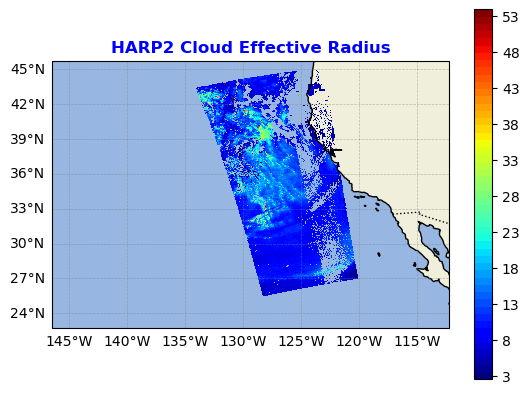

In [10]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
cmap_name='jet'
#ax.set_title('Cloud Phase for 2.1µm retrievals \n 0 - no cloud mask, 1 - clear, 2 - water cloud, 3 - ice cloud, 4 - unknown')
data = HARP2_CLD.retr.cloud_bow_droplet_effective_radius
cmap = plt.get_cmap(cmap_name, np.nanmax(data) - np.nanmin(data) + 1)
# set limits .5 outside true range
# fig,ax=plt.subplots()
mat = ax.pcolormesh(HARP2_CLD.geo.longitude, HARP2_CLD.geo.latitude, data, transform=ccrs.PlateCarree(),
                     cmap=cmap, vmin=np.nanmin(data) - 0.5,
                     vmax=np.nanmax(data) + 0.5, shading="nearest", rasterized=True)
ax.set_aspect("equal")
ax.set_aspect("equal")
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('HARP2 Cloud Effective Radius', fontsize=12, color='b', fontweight='bold')
gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
cax = plt.colorbar(mat, ax=ax,ticks=np.arange(np.nanmin(data), np.nanmax(data) + 1, 5))

### Plot the Cloud Bow Effective Variance retrieval

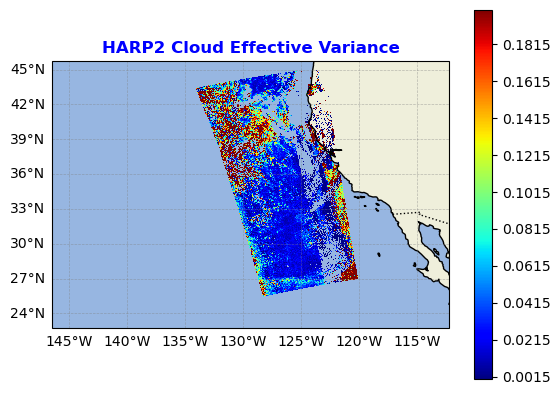

In [11]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
cmap_name='jet'

data = HARP2_CLD.retr.cloud_bow_droplet_effective_variance
cmap = plt.get_cmap(cmap_name, np.nanmax(data) - np.nanmin(data) + 1)

# fig,ax=plt.subplots()
mat = ax.pcolormesh(HARP2_CLD.geo.longitude, HARP2_CLD.geo.latitude, data, transform=ccrs.PlateCarree(),
                     cmap=cmap_name, vmin=0, vmax=0.2, shading="nearest", rasterized=True)
ax.set_aspect("equal")
ax.set_aspect("equal")
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('HARP2 Cloud Effective Variance', fontsize=12, color='b', fontweight='bold')
gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
cax = plt.colorbar(mat, ax=ax,ticks=np.arange(np.nanmin(data), np.nanmax(data), 0.02))

### Plot the OCI Cloud effective radius retrieval

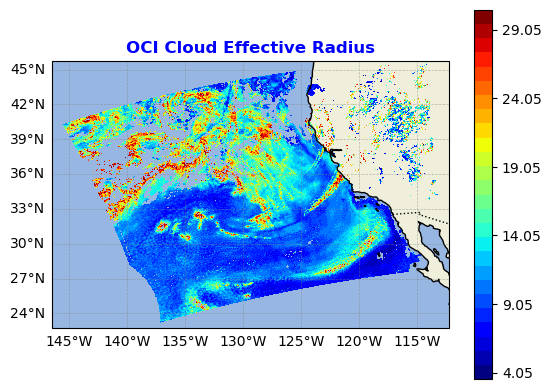

In [12]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
cmap_name='jet'
#ax.set_title('Cloud Phase for 2.1µm retrievals \n 0 - no cloud mask, 1 - clear, 2 - water cloud, 3 - ice cloud, 4 - unknown')
data = OCI_CLD.ds.cer_21_water_cloud.values
cmap = plt.get_cmap(cmap_name, np.nanmax(data) - np.nanmin(data) + 1)
# set limits .5 outside true range
# fig,ax=plt.subplots()
mat = ax.pcolormesh(OCI_CLD.ds.longitude, OCI_CLD.ds.latitude, data, transform=ccrs.PlateCarree(),
                     cmap=cmap, vmin=np.nanmin(data) - 0.5, vmax=np.nanmax(data) + 0.5, 
                    shading="nearest", rasterized=True)
ax.set_aspect("equal")
ax.set_aspect("equal")
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('OCI Cloud Effective Radius', fontsize=12, color='b', fontweight='bold')
gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
cax = plt.colorbar(mat, ax=ax,ticks=np.arange(np.nanmin(data), np.nanmax(data) + 1, 5))

### Scatter plot of OCI vs HARP-2 CER

In [13]:
HARP2_CLD.retr.cloud_bow_droplet_effective_radius.shape

(395, 519)

In [14]:
commond_index = (OCI_CLD.ds.cer_21_water_cloud.values > 0.0) & (HARP2_CLD.retr.cloud_bow_droplet_effective_radius > 0.0)

In [15]:
commond_index.shape

(395, 519)

In [16]:
from matplotlib import cm, colors
def scatter_plot_cer(x,y,c,title=None):
    # 2) normalize your variance into [0,1] for the colormap
    norm = colors.Normalize(vmin=c.min(), vmax=c.max())
    
    # 3) pick a colormap
    cmap = cm.get_cmap("viridis")
    
    # 4) map your normalized values to RGBA
    edge_colors = cmap(norm(c))   # an (N,4) array of RGBA
    
    # 5) scatter with open circles (facecolors='none') and colored edges
    fig, ax = plt.subplots()
    sc = ax.scatter(x, y, marker='o', s=50, facecolors='none', edgecolors=edge_colors, linewidths=1)
    
    # 6) add a colorbar. We need a ScalarMappable for that:
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])       # you can pass an empty array here
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Droplet variance')
    
    # 7) decorate
    ax.set_xlim([4, 30])
    ax.set_ylim([4, 30])
    ax.plot([4, 30], [4, 30], 'k--')
    ax.set_xlabel(r'OCI CER21 [$\mu m$]')
    ax.set_ylabel(r'HARP2 CER [$\mu m$]')
    if title:
        ax.set_title(title)
    
    plt.show()

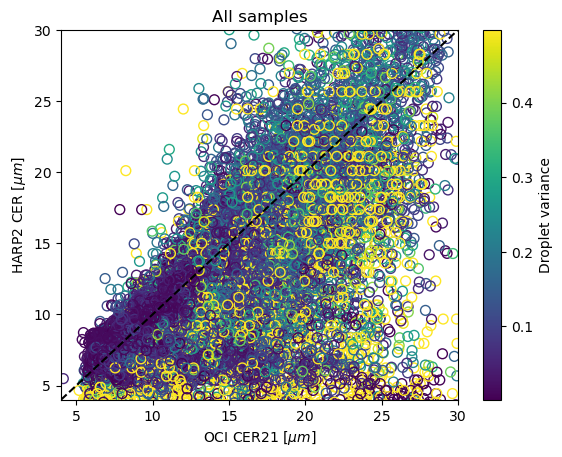

In [17]:
# 1) pull out your arrays and mask
OCI_CER = OCI_CLD.ds.cer_21_water_cloud.values
HARP2_CER = HARP2_CLD.retr.cloud_bow_droplet_effective_radius.values
HARP2_CEV = HARP2_CLD.retr.cloud_bow_droplet_effective_variance.values

mask_all = (HARP2_CER > 0) & (OCI_CER > 0) 
mask_small_cev = (OCI_CER > 0) & (HARP2_CER > 0) & (HARP2_CEV<0.1)
mask_large_cev = (OCI_CER > 0) & (HARP2_CER > 0) & (HARP2_CEV>0.3)

scatter_plot_cer(OCI_CER[mask_all], HARP2_CER[mask_all], HARP2_CEV[mask_all], 'All samples')

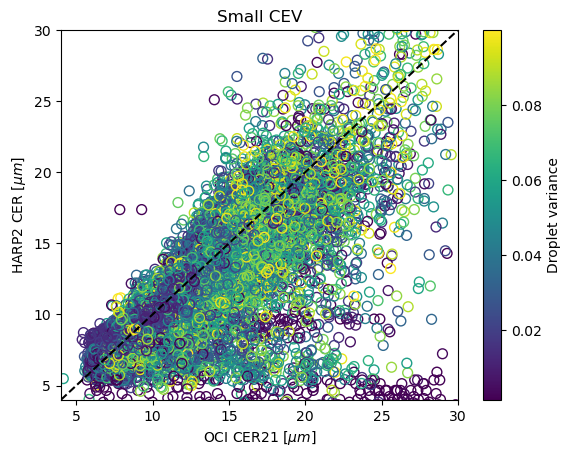

In [18]:
scatter_plot_cer(OCI_CER[mask_small_cev], HARP2_CER[mask_small_cev], HARP2_CEV[mask_small_cev], 'Small CEV')

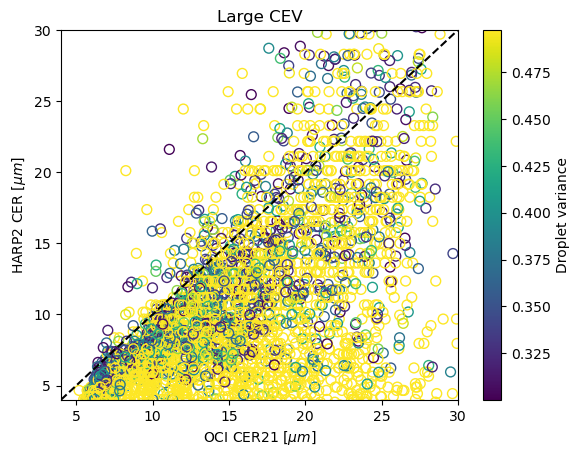

In [19]:
scatter_plot_cer(OCI_CER[mask_large_cev], HARP2_CER[mask_large_cev], HARP2_CEV[mask_large_cev], 'Large CEV')

In [20]:
np.corrcoef(OCI_CLD.ds.cer_21_water_cloud.values[commond_index],
           HARP2_CLD.retr.cloud_bow_droplet_effective_radius.values[commond_index])

array([[1.        , 0.69228411],
       [0.69228411, 1.        ]])

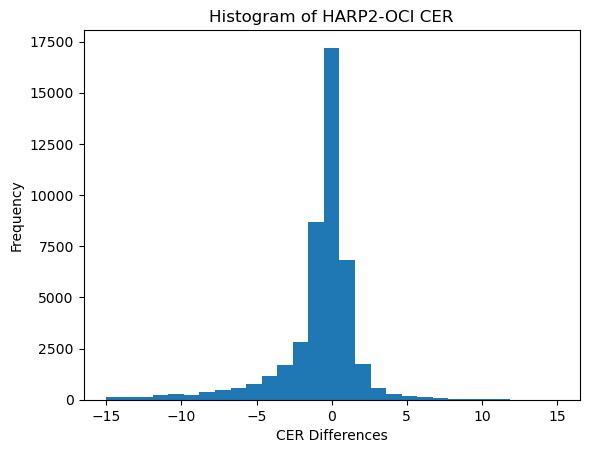

In [21]:
# Plot histogram of the specified values
CER_diff = HARP2_CER[mask_all] - OCI_CER[mask_all]
plt.hist(CER_diff, bins=np.linspace(-15,15,30,endpoint=True))
plt.xlabel('CER Differences')
plt.ylabel('Frequency')
plt.title('Histogram of HARP2-OCI CER')
plt.show()

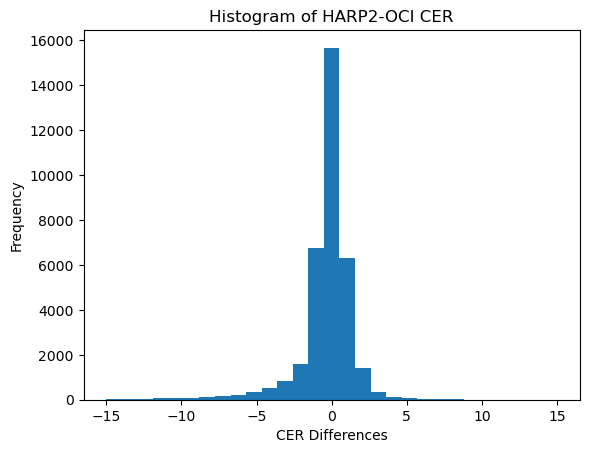

In [22]:
# Plot histogram of the specified values
CER_diff = HARP2_CER[mask_small_cev] - OCI_CER[mask_small_cev]
plt.hist(CER_diff, bins=np.linspace(-15,15,30, endpoint=True))
plt.xlabel('CER Differences')
plt.ylabel('Frequency')
plt.title('Histogram of HARP2-OCI CER')
plt.show()

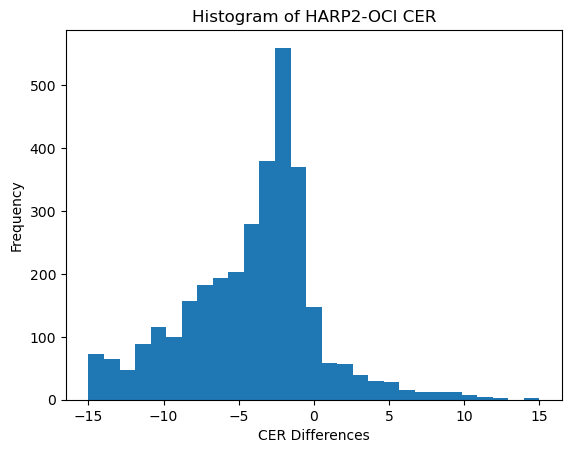

In [23]:
# Plot histogram of the specified values
CER_diff = HARP2_CER[mask_large_cev] - OCI_CER[mask_large_cev]
plt.hist(CER_diff, bins=np.linspace(-15,15,30, endpoint=True))
plt.xlabel('CER Differences')
plt.ylabel('Frequency')
plt.title('Histogram of HARP2-OCI CER')
plt.show()

## Collocated data

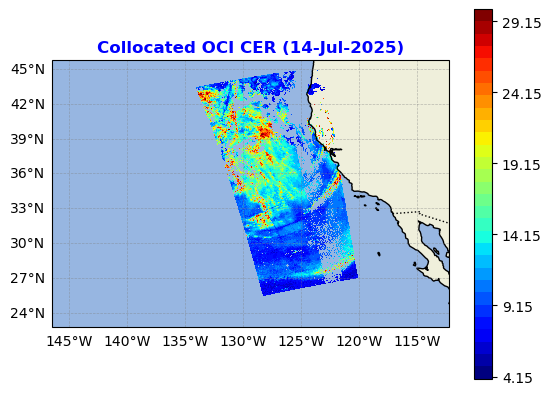

In [24]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
cmap_name='jet'
# ax.set_title('Cloud Phase for 2.1µm retrievals \n 0 - no cloud mask, 1 - clear, 2 - water cloud, 3 - ice cloud, 4 - unknown')
data = np.where(mask_all, OCI_CLD.ds.cer_21_water_cloud.values, np.nan)    # OCI_CLD.ds.cer_21_water_cloud.values[mask_all]
cmap = plt.get_cmap(cmap_name, 30)
# set limits .5 outside true range
# fig,ax=plt.subplots()
mat = ax.pcolormesh(OCI_CLD.ds.longitude.values, OCI_CLD.ds.latitude.values, data, transform=ccrs.PlateCarree(),
                     cmap=cmap, vmin=4,vmax=30,shading="nearest", rasterized=True)
ax.set_aspect("equal")
ax.set_aspect("equal")
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Collocated OCI CER (14-Jul-2025)', fontsize=12, color='b', fontweight='bold')
gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
cax = plt.colorbar(mat, ax=ax,ticks=np.arange(np.nanmin(data), np.nanmax(data) + 1,5))

In [25]:
np.nanmax(data)
np.min(OCI_CLD.ds.longitude.values)
np.max(OCI_CLD.ds.longitude.values)
np.min(OCI_CLD.ds.latitude.values)
np.max(OCI_CLD.ds.latitude.values)

np.float32(45.70878)

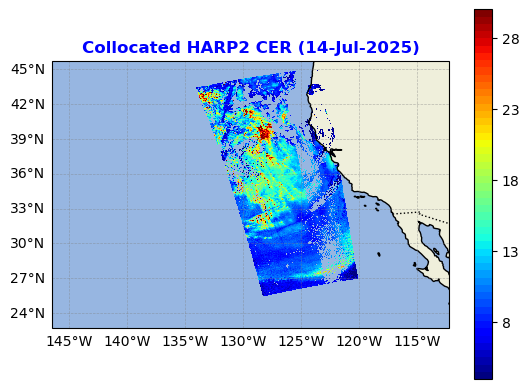

In [26]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
cmap_name='jet'
# ax.set_title('Cloud Phase for 2.1µm retrievals \n 0 - no cloud mask, 1 - clear, 2 - water cloud, 3 - ice cloud, 4 - unknown')
data = np.where(mask_all, HARP2_CLD.retr.cloud_bow_droplet_effective_radius.values, np.nan)    #OCI_CLD.ds.cer_21_water_cloud.values[mask_all]
cmap = plt.get_cmap(cmap_name, np.nanmax(data) - np.nanmin(data) + 1)
# set limits .5 outside true range
# fig,ax=plt.subplots()
mat = ax.pcolormesh(OCI_CLD.ds.longitude.values, OCI_CLD.ds.latitude.values, data, transform=ccrs.PlateCarree(),
                     cmap=cmap, vmin=4,vmax=30,shading="nearest", rasterized=True)
ax.set_aspect("equal")
ax.set_aspect("equal")
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Collocated HARP2 CER (14-Jul-2025)', fontsize=12, color='b', fontweight='bold')
gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
cax = plt.colorbar(mat, ax=ax,ticks=np.arange(np.nanmin(data), np.nanmax(data) + 1, 5))

In [27]:
np.nanmax(data)

np.float32(53.36896)

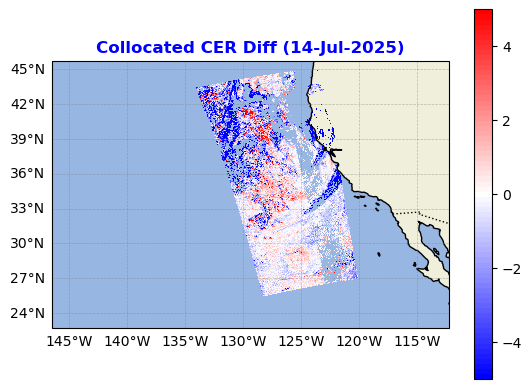

In [28]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
cmap_name='bwr'
 
CER_diff= HARP2_CLD.retr.cloud_bow_droplet_effective_radius.values - OCI_CLD.ds.cer_21_water_cloud.values
#ax.set_title('Cloud Phase for 2.1µm retrievals \n 0 - no cloud mask, 1 - clear, 2 - water cloud, 3 - ice cloud, 4 - unknown')
data = np.where(mask_all, CER_diff, np.nan) #OCI_CLD.ds.cer_21_water_cloud.values[mask_all]
cmap = plt.get_cmap(cmap_name, np.nanmax(data) - np.nanmin(data) + 1)
# set limits .5 outside true range
# fig,ax=plt.subplots()
mat = ax.pcolormesh(OCI_CLD.ds.longitude.values, OCI_CLD.ds.latitude.values, data, transform=ccrs.PlateCarree(),
                     cmap=cmap, vmin=-5,vmax=5, shading="nearest", rasterized=True)
ax.set_aspect("equal")
ax.set_aspect("equal")
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Collocated CER Diff (14-Jul-2025)', fontsize=12, color='b', fontweight='bold')
gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
cax = plt.colorbar(mat, ax=ax)

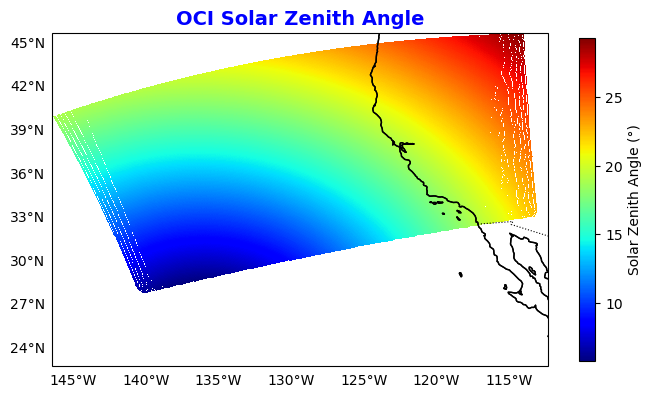

In [29]:
# Load dataset (L1C geolocation)
ds = xr.open_dataset("/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L1C_SCI/PACE_OCI.20250703T210657.L1C.V3.5km.nc", group="geolocation_data")
data = ds["solar_zenith_angle"].isel(number_of_views=1)
# data = ds["solar_zenith_angle"][:,:,1]

lon = ds["longitude"]
lat = ds["latitude"]

# Plot
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
img = ax.pcolormesh(lon, lat, data, cmap="jet", shading="auto")

ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor="black")
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)
ax.set_title("OCI Solar Zenith Angle", fontsize=14, color="b", fontweight="bold")

gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False
gl.xlines = False
gl.ylines = False

# Colorbar
cbar = plt.colorbar(img, ax=ax, orientation="vertical", shrink=0.7, pad=0.05)
cbar.set_label("Solar Zenith Angle (°)")

plt.show()

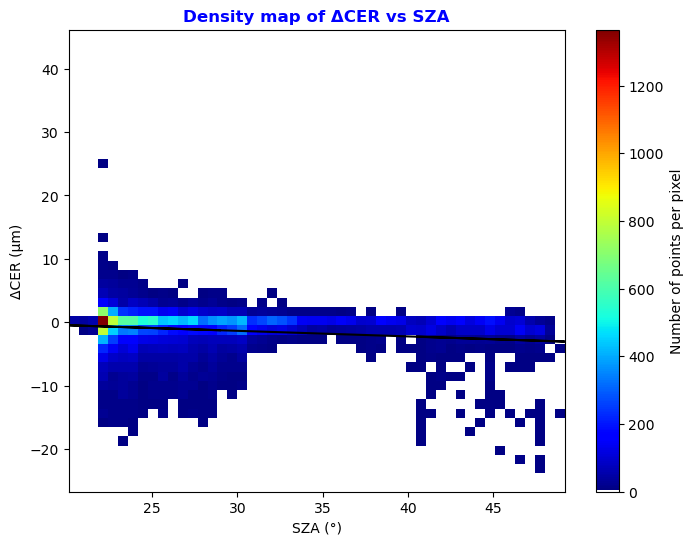

In [34]:
CER_diff= HARP2_CLD.retr.cloud_bow_droplet_effective_radius.values - OCI_CLD.ds.cer_21_water_cloud.values
data = np.where(mask_all, CER_diff, np.nan).flatten()

ds = xr.open_dataset("/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L1C_SCI/PACE_OCI.20250703T210657.L1C.V3.5km.nc", group="geolocation_data")
# data_sza = ds["solar_zenith_angle"].isel(number_of_views=1).values.ravel()
# data_sza = ds["solar_azimuth_angle"].isel(number_of_views=1).values.ravel()
data_sza = ds["sensor_zenith_angle"].isel(number_of_views=1).values.ravel()

mask_hist = ~ (np.isnan(data) | np.isnan(data_sza))
data = data[mask_hist]
data_sza = data_sza[mask_hist]


original_jet = plt.cm.get_cmap('jet', 256)
new_colors = original_jet(np.linspace(0, 1, 256))
new_colors[0, :] = np.array([1, 1, 1, 1])
white_jet_cmap = ListedColormap(new_colors)

def using_hist2d(fig, ax, x, y, bins=(50, 50)):
    h, xedges, yedges, im = ax.hist2d(x, y, bins=bins, cmap=white_jet_cmap)
    fig.colorbar(im, ax=ax, label='Number of points per pixel')

fig, ax = plt.subplots(figsize=(8,6))
using_hist2d(fig, ax, data_sza, data, bins=(50, 50))

# best fit
coefficients = np.polyfit(data_sza, data, 1)
line_of_best_fit = np.poly1d(coefficients)
plt.plot(data_sza, line_of_best_fit(data_sza), color='k')

ax.set_xlabel("SZA (°)")
ax.set_ylabel("ΔCER (µm)")
ax.set_title("Density map of ΔCER vs SZA", fontsize=12, color="b", fontweight="bold")
# plt.savefig('Density_map.png', dpi=300)
plt.show()

In [ ]:
data.shape